In [1]:
import os
import joblib
from IPython.display import display, Latex

from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score, hamming_loss
from scipy.stats import gaussian_kde

import numpy as np
import matplotlib.pyplot as plt

import torch

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

# Accuracies

## Vanilla LR models trained on each dataset

### Evaluated on all samples

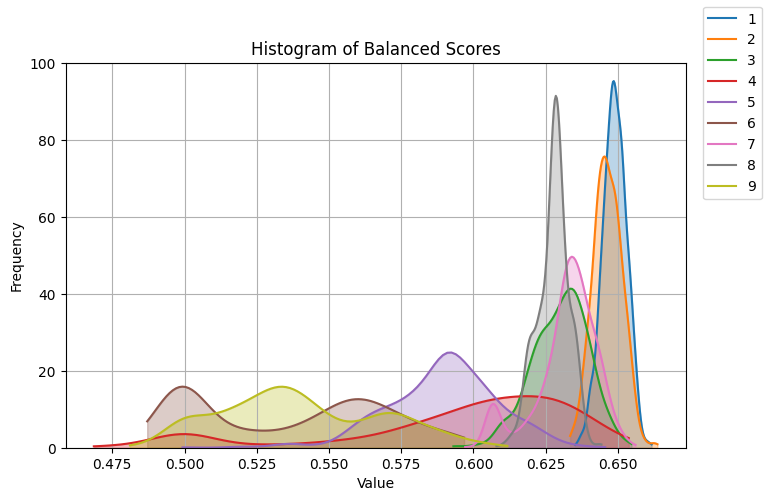

In [9]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 5))

for did in range(len(datasets_ids)):
    cond_vector = torch.zeros(len(datasets_ids))
    cond_vector[did] = 1
    mask = (data['labels'] == cond_vector).all(dim=1)
    accs = data['bal_accs'][mask]
    aucs = data['auc_scores'][mask]
    
    data_plot = accs[:, -1].numpy()
    
    kde = gaussian_kde(data_plot)  # fits a smooth PDF
    x = np.linspace(data_plot.min(), data_plot.max(), 100)
    
    y = kde(x)
    color = colors[did]
    label = datasets_ids[did]
    ax.plot(x, y, color=color, label=label)
    ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve
    
    # xlim = [0.45, 0.75]

ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_title(f"Histogram of Balanced Scores")
# ax.set_xlim(xlim)
ax.set_ylim(ymin=0)
ax.grid(True, zorder=-1)

fig.legend()

# Show plot
plt.show()

### Evaluated on samples from each dataset

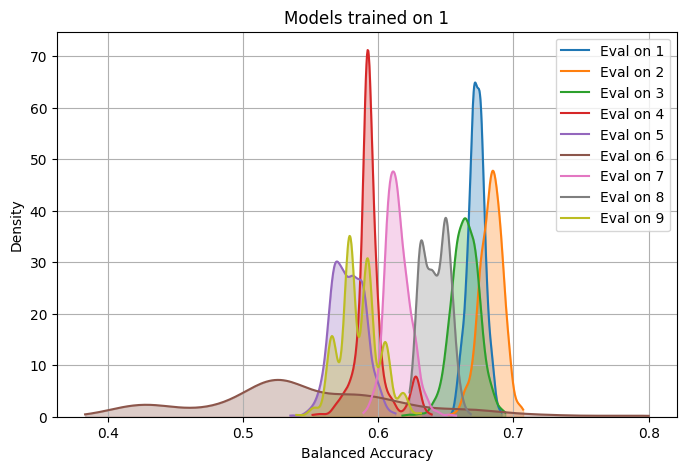

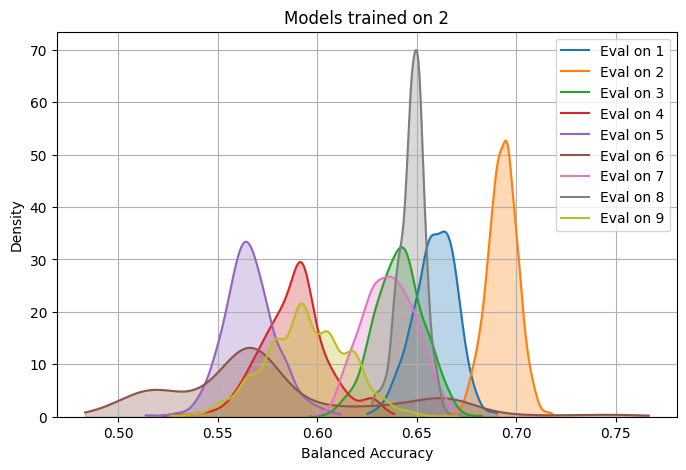

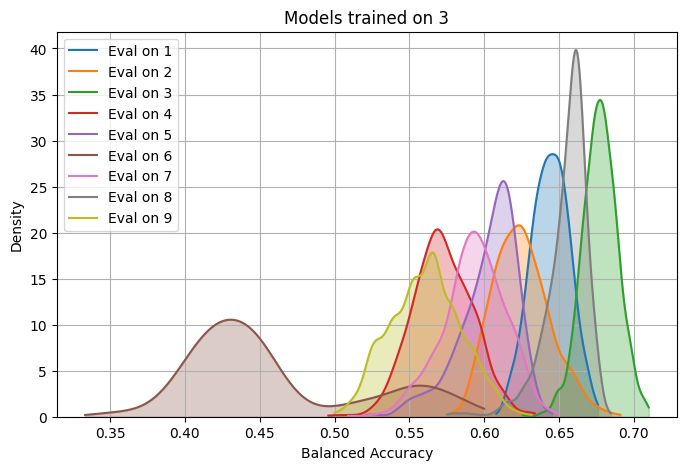

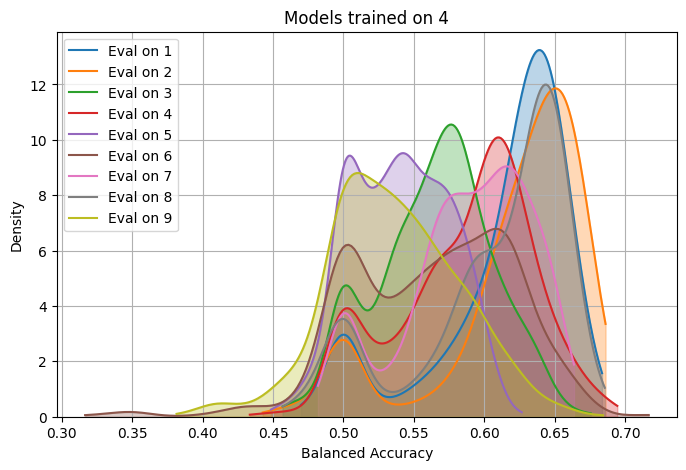

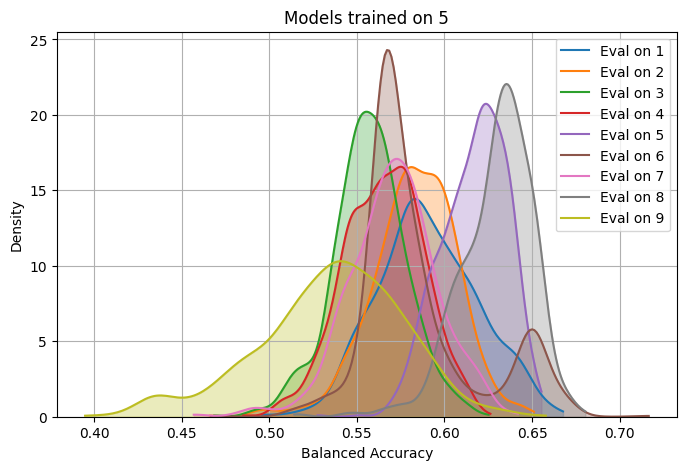

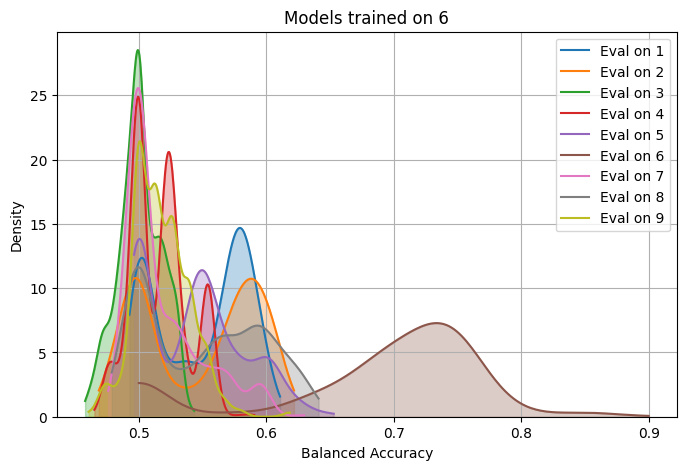

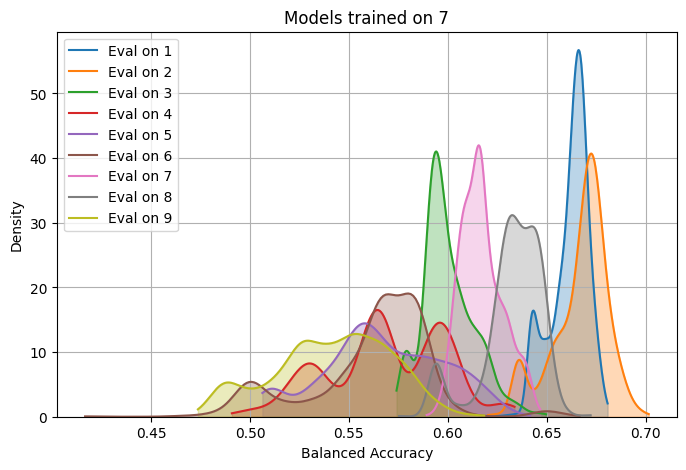

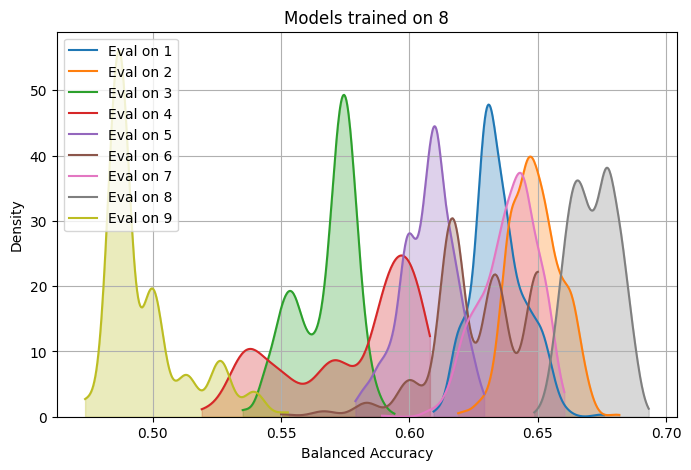

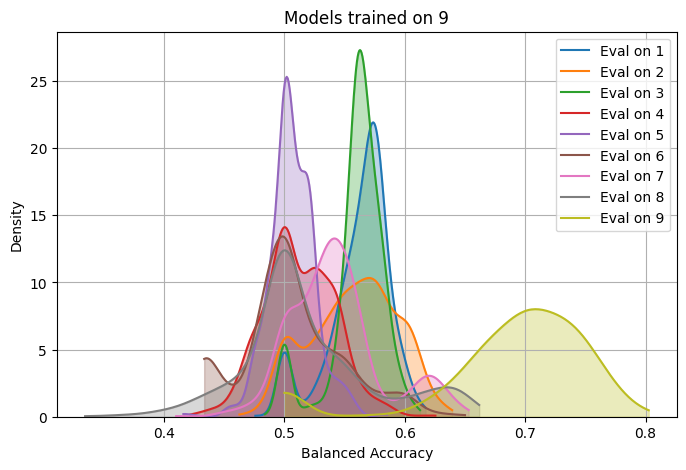

In [10]:
# Config
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette

# Loop over training dataset IDs
for train_did in range(len(datasets_ids)):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Condition vector for models trained on train_did
    cond_vector = torch.zeros(len(datasets_ids))
    cond_vector[train_did] = 1
    mask = (data['labels'] == cond_vector).all(dim=1)

    accs = data['bal_accs'][mask]  # shape: (#models, #datasets)

    # Now loop over evaluation datasets
    for test_did in range(len(datasets_ids)):
        data_plot = accs[:, test_did].numpy()

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)

        color = colors[test_did % len(colors)]
        label = f"Eval on {datasets_ids[test_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    ax.set_xlabel("Balanced Accuracy")
    ax.set_ylabel("Density")
    ax.set_title(f"Models trained on {datasets_ids[train_did]}")
    ax.set_ylim(ymin=0)
    ax.grid(True, zorder=-1)
    ax.legend()

    plt.show()

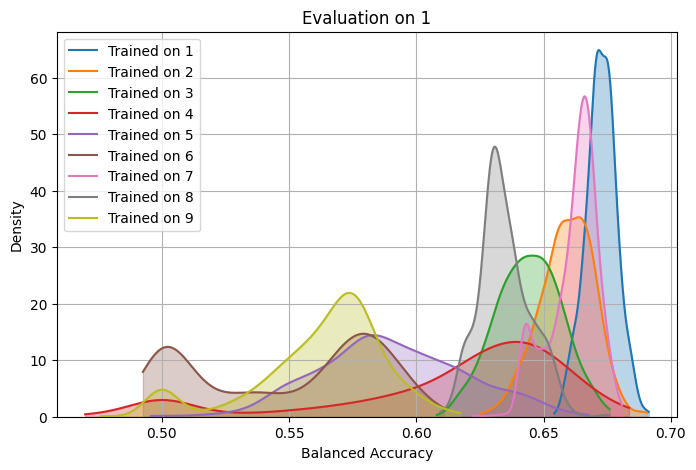

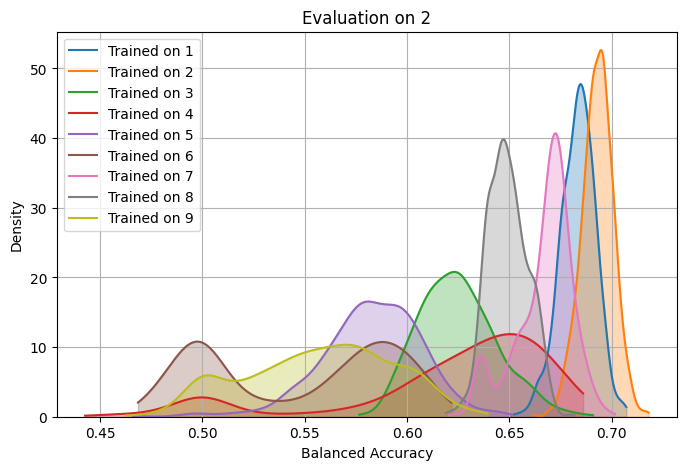

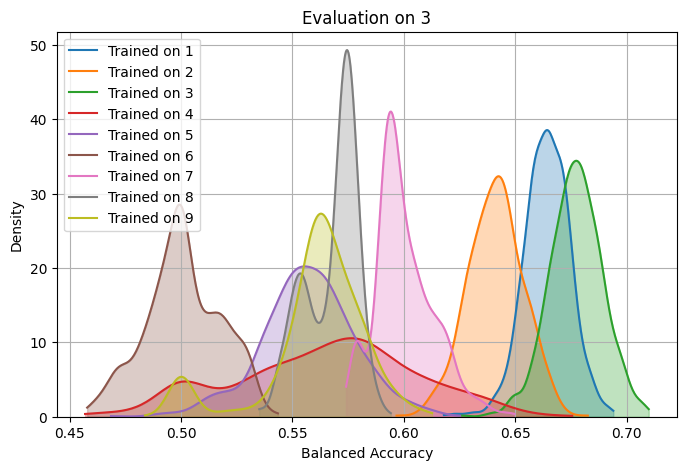

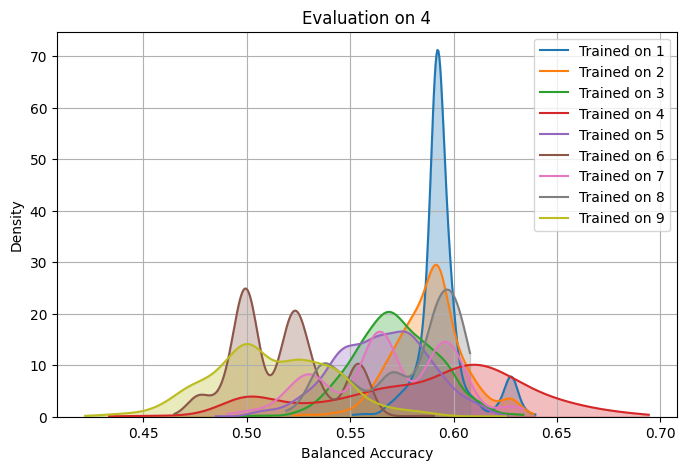

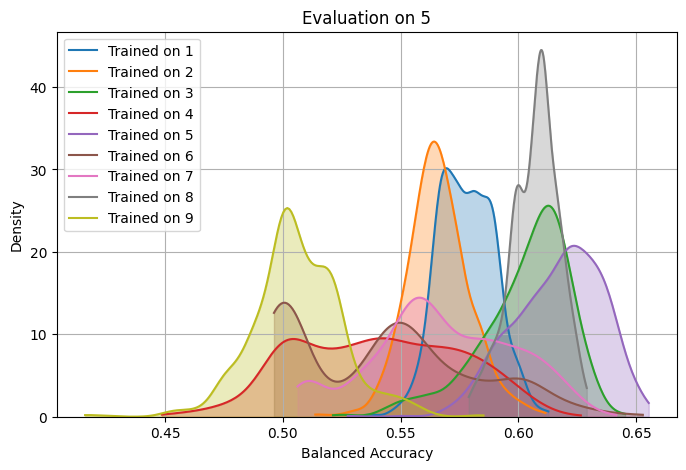

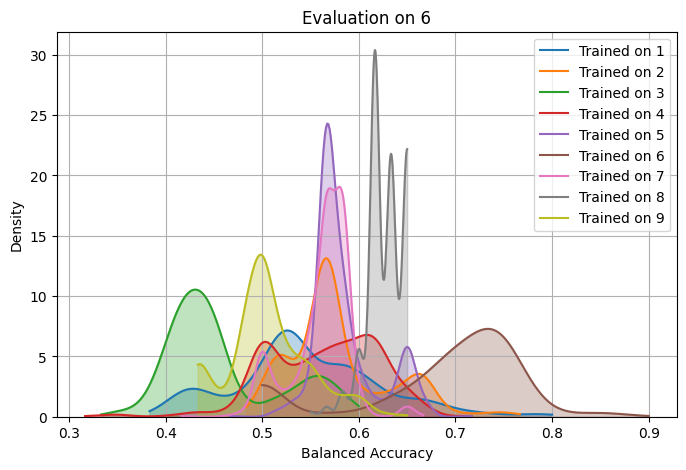

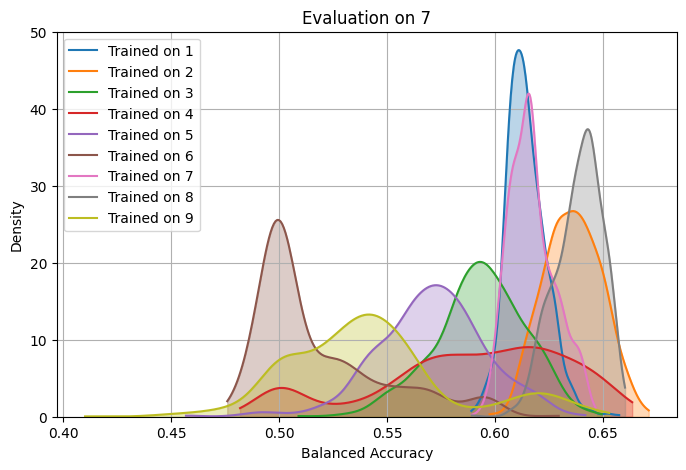

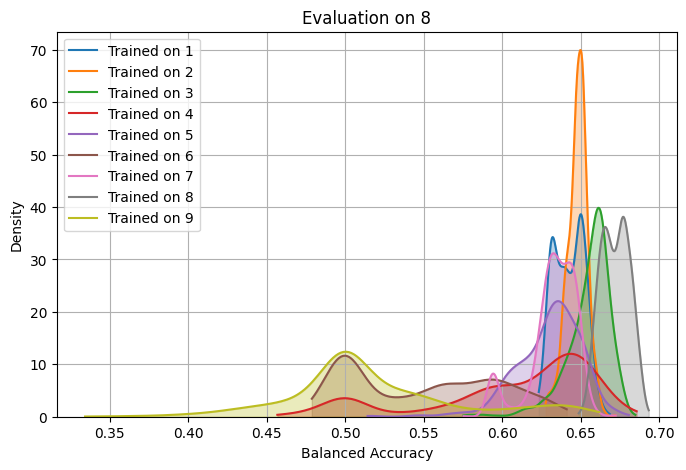

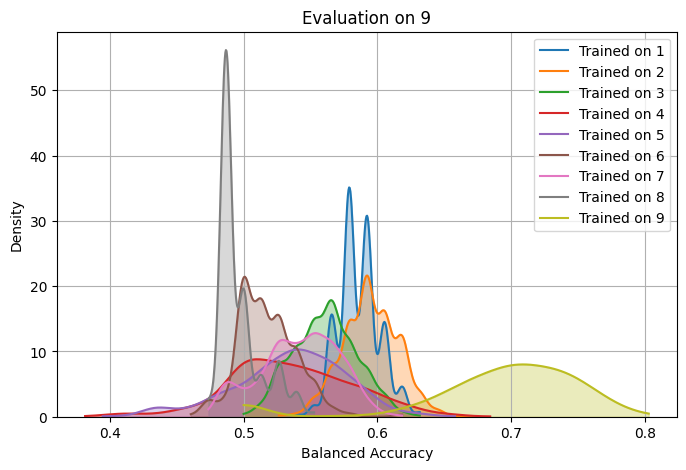

In [12]:
# Config
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette

# Loop over evaluation datasets
for eval_did in range(len(datasets_ids)):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Now loop over training datasets
    for train_did in range(len(datasets_ids)):
        cond_vector = torch.zeros(len(datasets_ids))
        cond_vector[train_did] = 1
        mask = (data['labels'] == cond_vector).all(dim=1)

        accs = data['bal_accs'][mask]  # shape: (#models, #datasets)
        data_plot = accs[:, eval_did].numpy()  # evaluation fixed

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)

        color = colors[train_did % len(colors)]
        label = f"Trained on {datasets_ids[train_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    ax.set_xlabel("Balanced Accuracy")
    ax.set_ylabel("Density")
    ax.set_title(f"Evaluation on {datasets_ids[eval_did]}")
    ax.set_ylim(ymin=0)
    ax.grid(True, zorder=-1)
    ax.legend()

    plt.show()

## Vanilla LR models trained on data that contained each dataset

### Evaluated on all samples

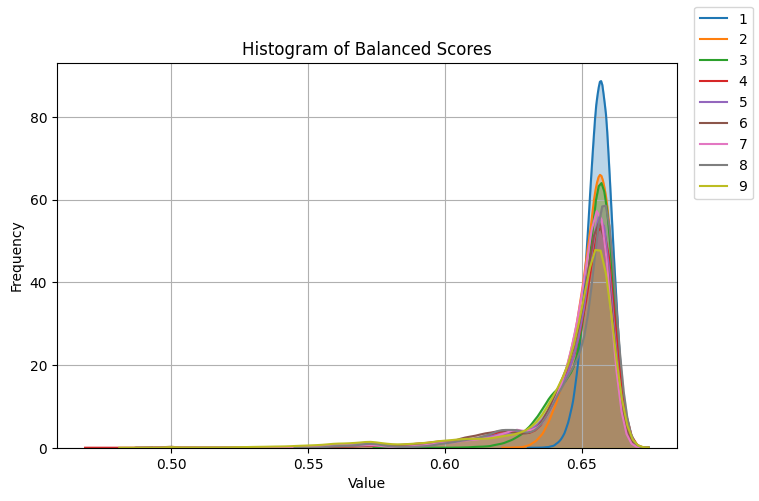

In [13]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 5))

for did in range(len(datasets_ids)):
    mask = data['labels'][:, did] == 1
    accs = data['bal_accs'][mask]
    aucs = data['auc_scores'][mask]
    
    data_plot = accs[:, -1].numpy()
    
    kde = gaussian_kde(data_plot)  # fits a smooth PDF
    x = np.linspace(data_plot.min(), data_plot.max(), 100)
    
    y = kde(x)
    color = colors[did]
    label = datasets_ids[did]
    ax.plot(x, y, color=color, label=label)
    ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve
    
    # xlim = [0.45, 0.75]

ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_title(f"Histogram of Balanced Scores")
# ax.set_xlim(xlim)
ax.set_ylim(ymin=0)
ax.grid(True, zorder=-1)

fig.legend()

# Show plot
plt.show()

### Evaluated on samples from each dataset

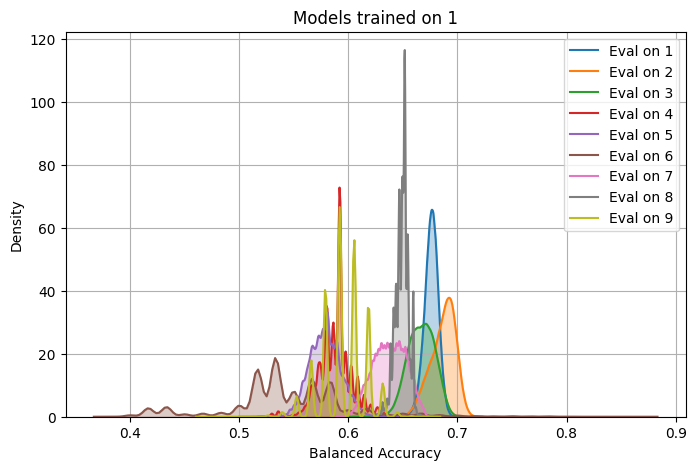

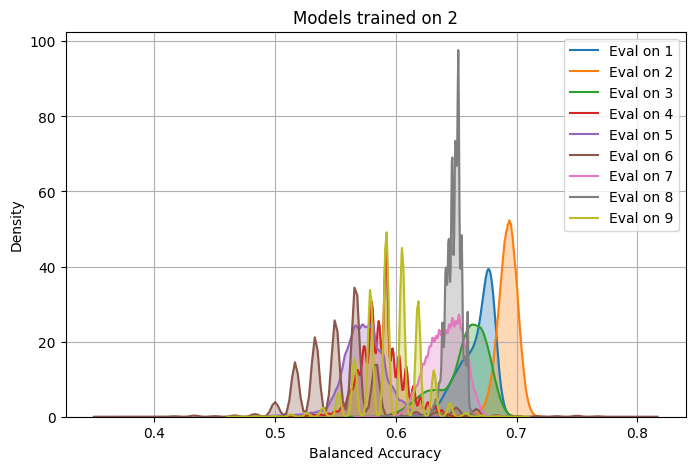

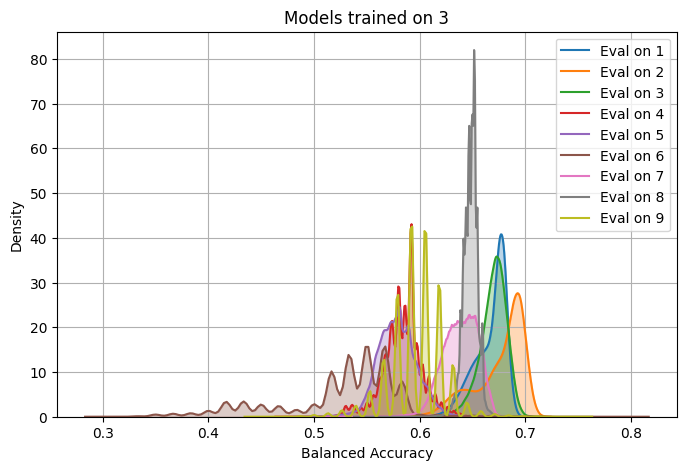

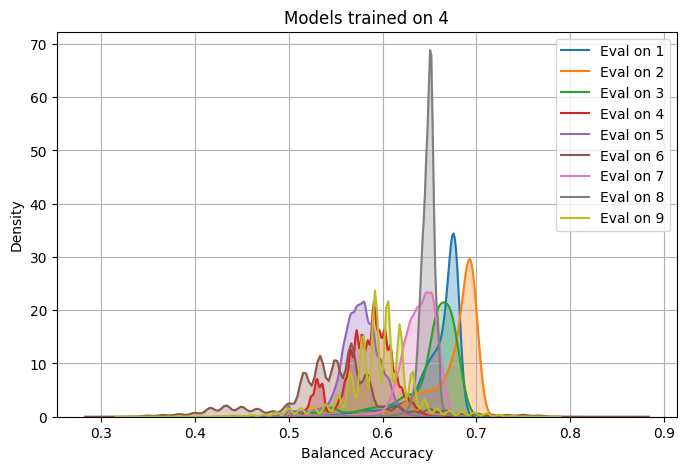

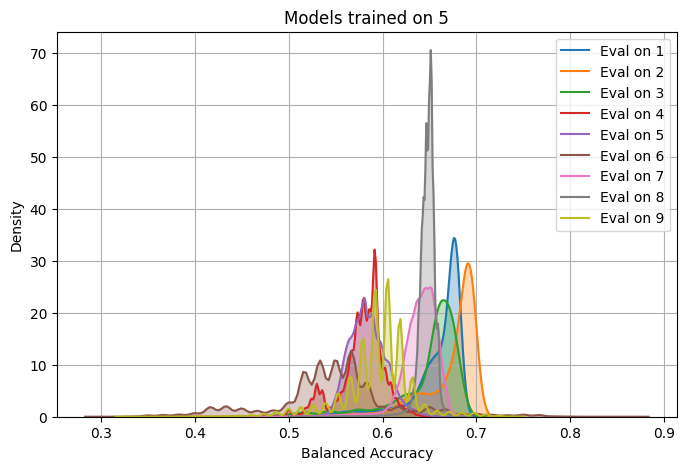

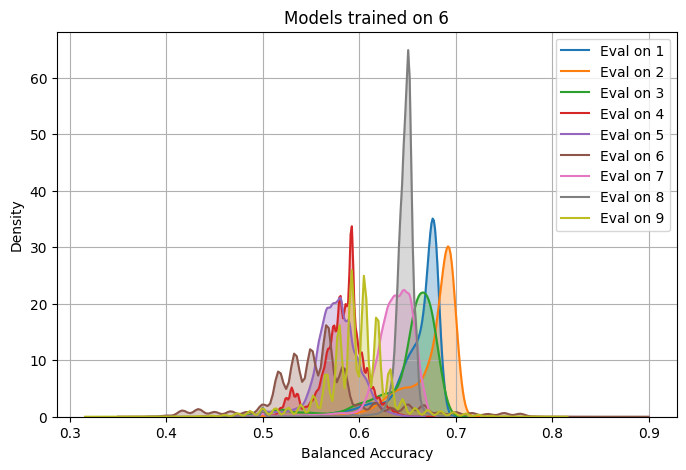

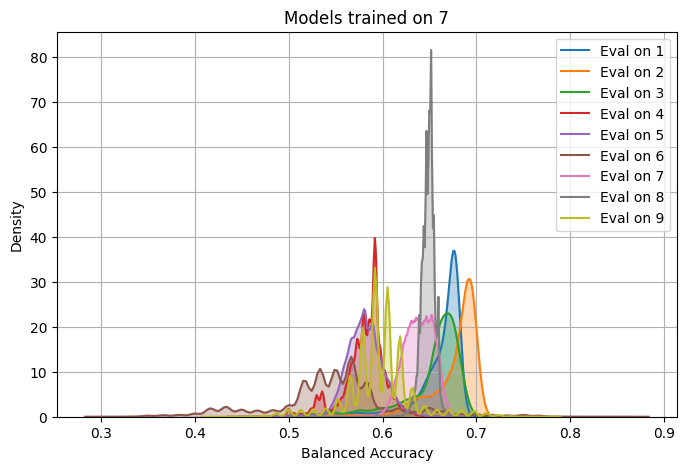

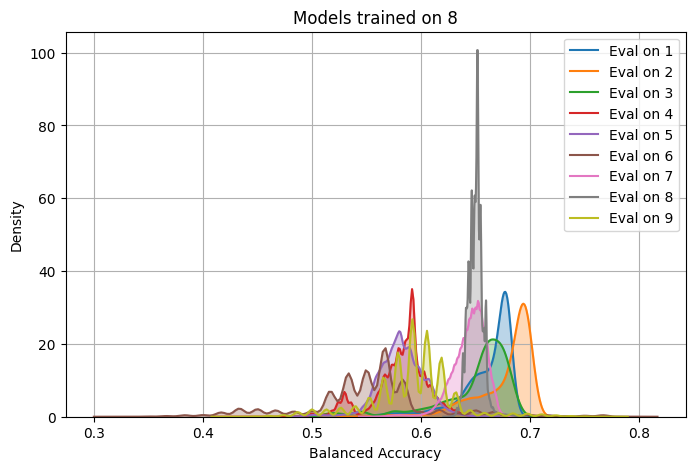

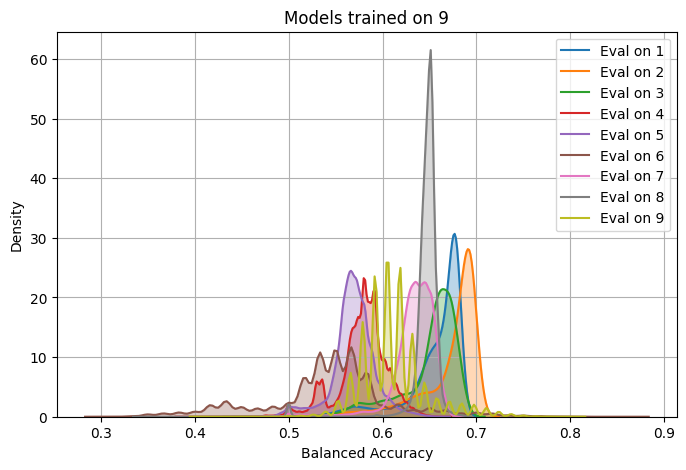

In [14]:
# Config
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette

# Loop over training dataset IDs
for train_did in range(len(datasets_ids)):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Condition vector for models trained on train_did
    mask = data['labels'][:, train_did] == 1
    
    accs = data['bal_accs'][mask]  # shape: (#models, #datasets)

    # Now loop over evaluation datasets
    for test_did in range(len(datasets_ids)):
        data_plot = accs[:, test_did].numpy()

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)

        color = colors[test_did % len(colors)]
        label = f"Eval on {datasets_ids[test_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    ax.set_xlabel("Balanced Accuracy")
    ax.set_ylabel("Density")
    ax.set_title(f"Models trained on {datasets_ids[train_did]}")
    ax.set_ylim(ymin=0)
    ax.grid(True, zorder=-1)
    ax.legend()

    plt.show()

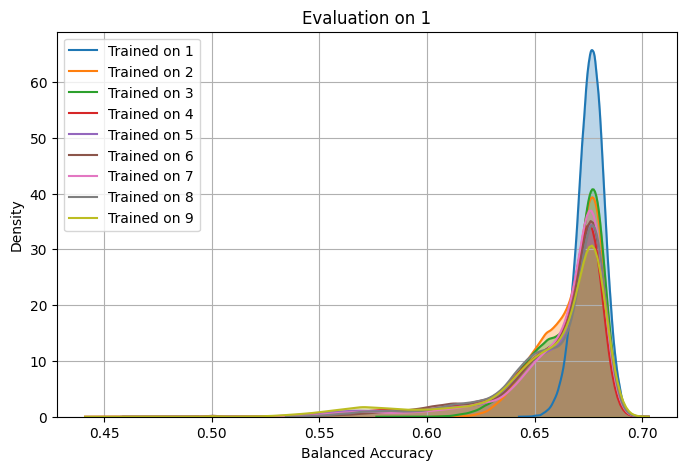

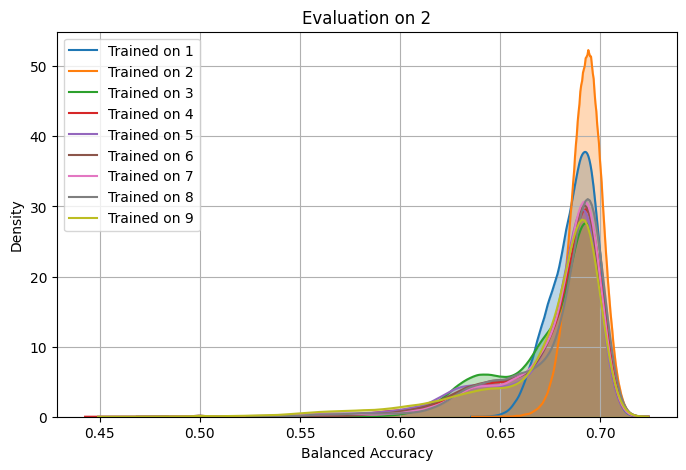

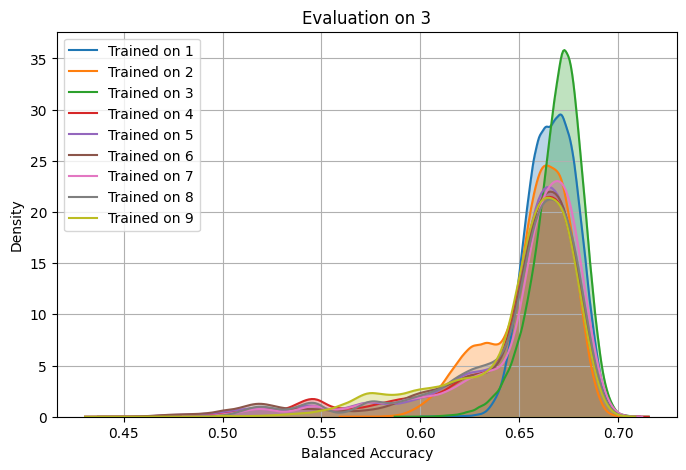

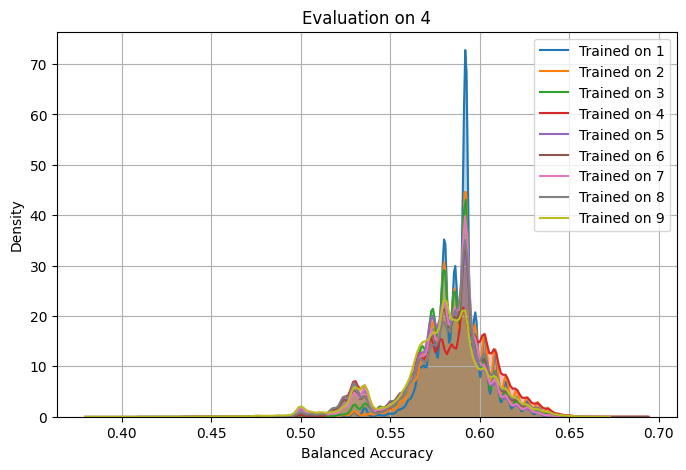

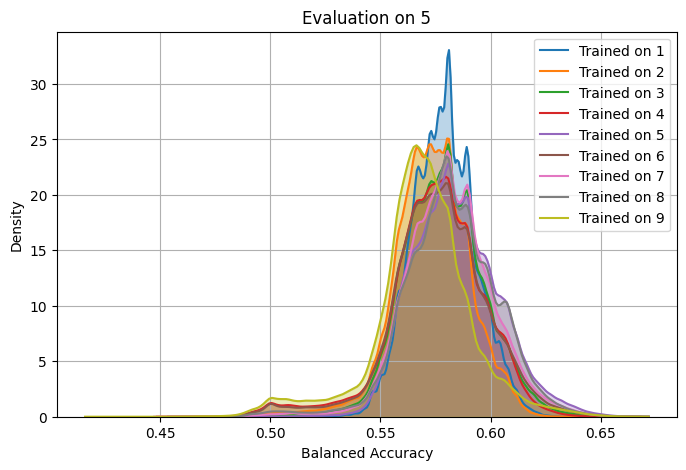

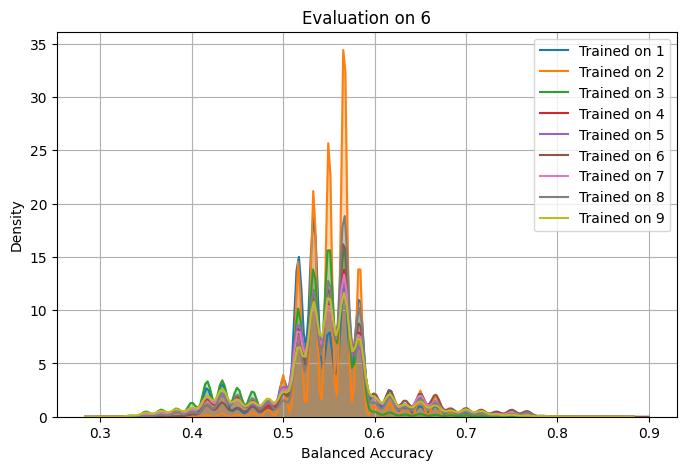

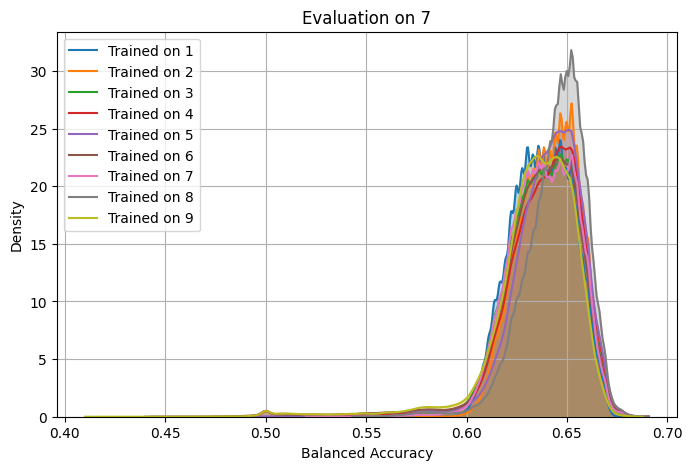

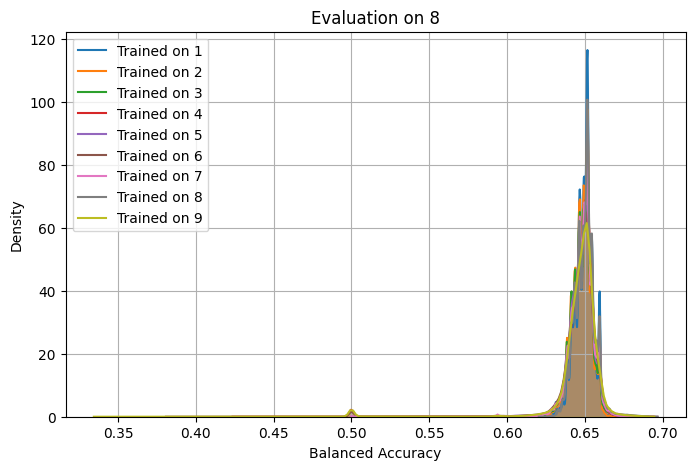

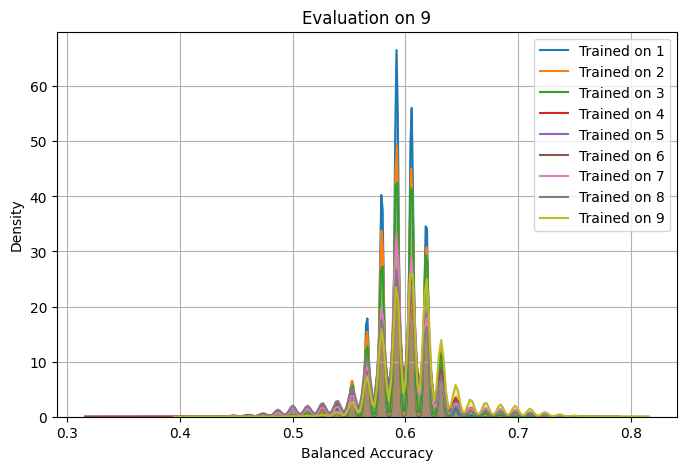

In [15]:
# Config
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette

# Loop over evaluation datasets
for eval_did in range(len(datasets_ids)):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Now loop over training datasets
    for train_did in range(len(datasets_ids)):
        mask = data['labels'][:, train_did] == 1

        accs = data['bal_accs'][mask]  # shape: (#models, #datasets)
        data_plot = accs[:, eval_did].numpy()  # evaluation fixed

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)

        color = colors[train_did % len(colors)]
        label = f"Trained on {datasets_ids[train_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    ax.set_xlabel("Balanced Accuracy")
    ax.set_ylabel("Density")
    ax.set_title(f"Evaluation on {datasets_ids[eval_did]}")
    ax.set_ylim(ymin=0)
    ax.grid(True, zorder=-1)
    ax.legend()

    plt.show()

## Comparison LR vs LR_priv vs TT

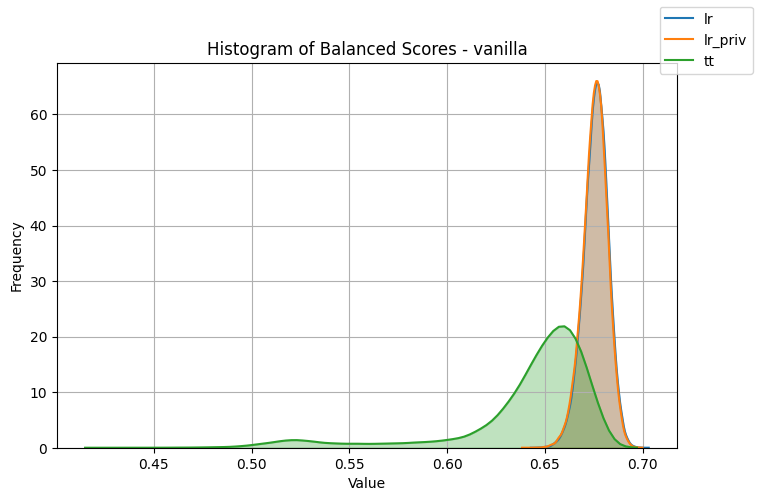

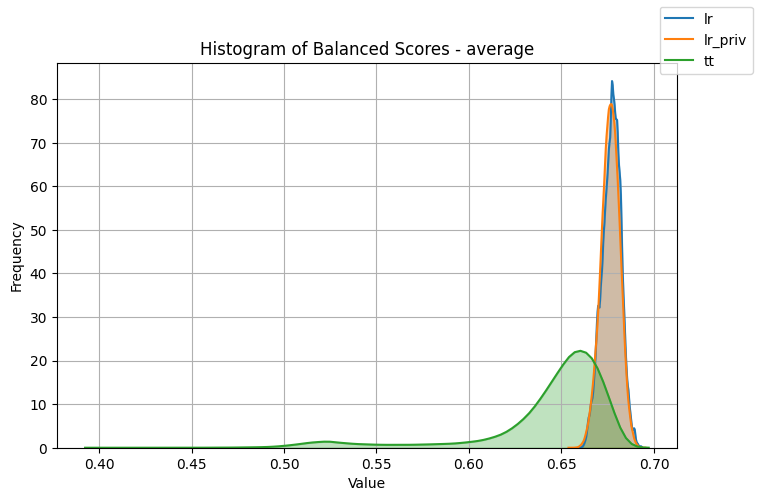

In [24]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors
mode_names_lst = ['lr', 'lr_priv', 'tt']

for model_type in ['vanilla', 'average']:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, model_name in enumerate(mode_names_lst):
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        mask = data['labels'][:, 0] == 1
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]
        
        data_plot = accs[:, 0].numpy()
        
        kde = gaussian_kde(data_plot)  # fits a smooth PDF
        x = np.linspace(data_plot.min(), data_plot.max(), 100)
        
        y = kde(x)
        color = colors[i]
        label = mode_names_lst[i]
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve
        
        # xlim = [0.45, 0.75]

    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Histogram of Balanced Scores - {model_type}")
    # ax.set_xlim(xlim)
    ax.set_ylim(ymin=0)
    ax.grid(True, zorder=-1)

    fig.legend()

    # Show plot
    plt.show()

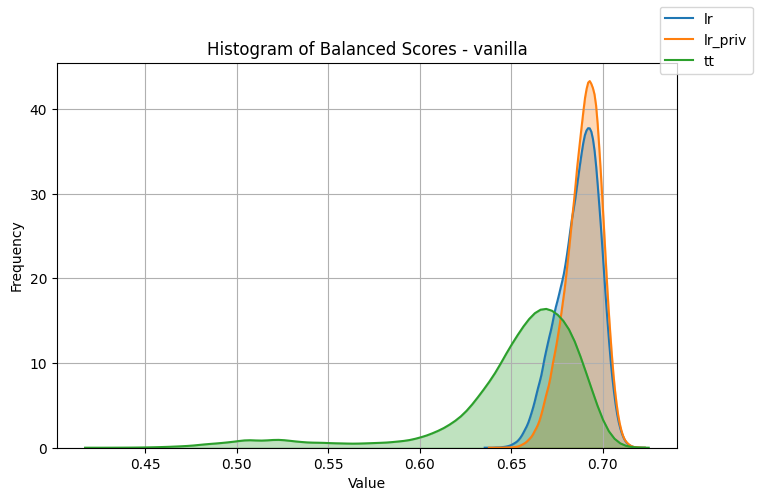

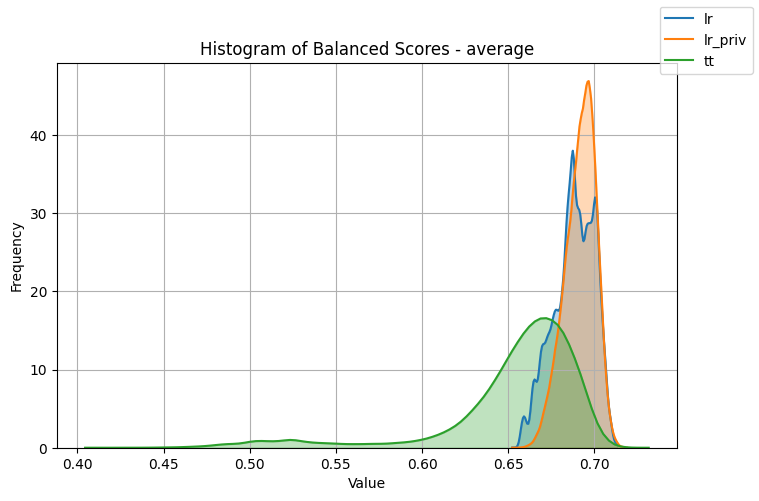

In [23]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors
mode_names_lst = ['lr', 'lr_priv', 'tt']

for model_type in ['vanilla', 'average']:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, model_name in enumerate(mode_names_lst):
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        mask = data['labels'][:, 0] == 1
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]
        
        data_plot = accs[:, 1].numpy()
        
        kde = gaussian_kde(data_plot)  # fits a smooth PDF
        x = np.linspace(data_plot.min(), data_plot.max(), 100)
        
        y = kde(x)
        color = colors[i]
        label = mode_names_lst[i]
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve
        
        # xlim = [0.45, 0.75]

    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Histogram of Balanced Scores - {model_type}")
    # ax.set_xlim(xlim)
    ax.set_ylim(ymin=0)
    ax.grid(True, zorder=-1)

    fig.legend()

    # Show plot
    plt.show()

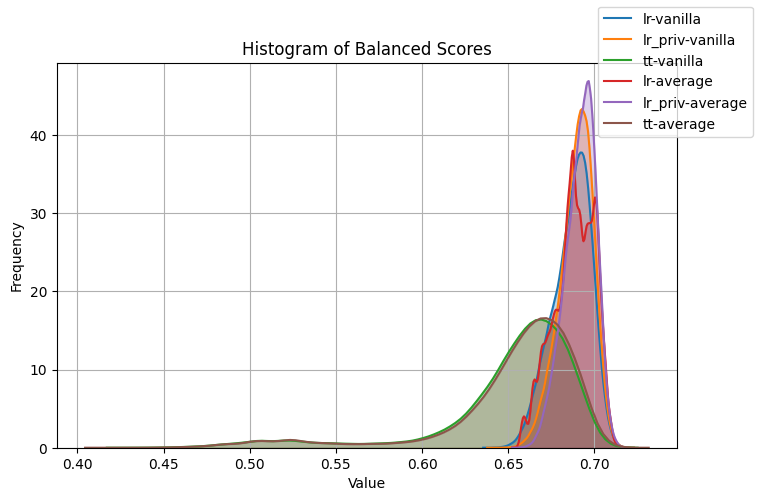

In [56]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors
mode_names_lst = ['lr', 'lr_priv', 'tt']

fig, ax = plt.subplots(figsize=(8, 5))

for j, model_type in enumerate(['vanilla', 'average']):
    for i, model_name in enumerate(mode_names_lst):
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        mask = data['labels'][:, 0] == 1
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]
        
        data_plot = accs[:, 1].numpy()
        
        kde = gaussian_kde(data_plot)  # fits a smooth PDF
        x = np.linspace(data_plot.min(), data_plot.max(), 100)
        
        y = kde(x)
        color = colors[i + 3*j]
        label = model_name + '-' + model_type
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve
        
        # xlim = [0.45, 0.75]

ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_title(f"Histogram of Balanced Scores")
# ax.set_xlim(xlim)
ax.set_ylim(ymin=0)
ax.grid(True, zorder=-1)

fig.legend()

# Show plot
plt.show()

## Comparison LR DP with different epsilons

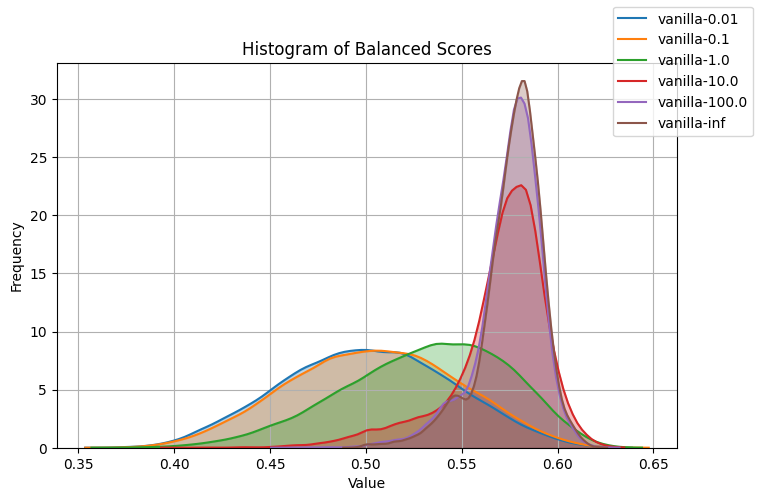

In [60]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors
epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

fig, ax = plt.subplots(figsize=(8, 5))

for j, model_type in enumerate(['vanilla']):
    for i, epsilon in enumerate(epsilon_list):
        data_dir = os.path.join(cwd, 'results', 'datasets', 'lr_dp',
                                scaler_type, model_type, 
                                f'params_multilabel_{epsilon}.pt')
        data = torch.load(data_dir, weights_only=True)
        
        accs = data['bal_accs']
        aucs = data['auc_scores']
        
        data_plot = accs[:, -1].numpy()
        
        kde = gaussian_kde(data_plot)  # fits a smooth PDF
        x = np.linspace(data_plot.min(), data_plot.max(), 100)
        
        y = kde(x)
        color = colors[i]
        label = model_type + '-' + str(epsilon)
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve
        
        # xlim = [0.45, 0.75]

ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_title(f"Histogram of Balanced Scores")
# ax.set_xlim(xlim)
ax.set_ylim(ymin=0)
ax.grid(True, zorder=-1)

fig.legend()

# Show plot
plt.show()

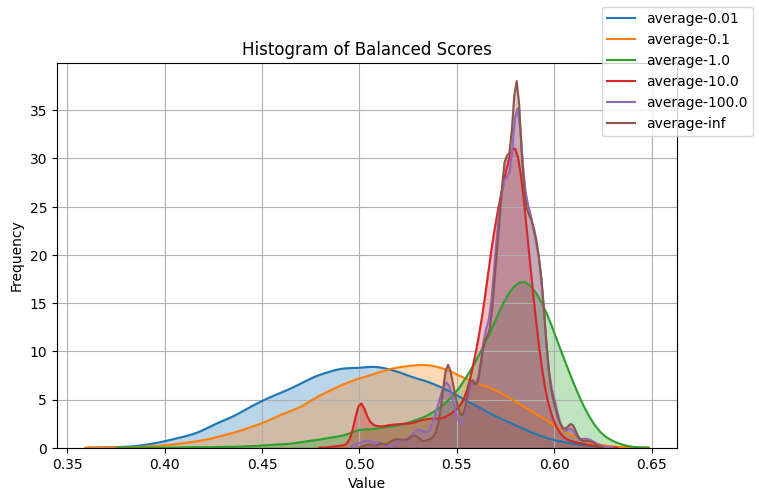

In [61]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors
epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

fig, ax = plt.subplots(figsize=(8, 5))

for j, model_type in enumerate(['average']):
    for i, epsilon in enumerate(epsilon_list):
        data_dir = os.path.join(cwd, 'results', 'datasets', 'lr_dp',
                                scaler_type, model_type, 
                                f'params_multilabel_{epsilon}.pt')
        data = torch.load(data_dir, weights_only=True)
        
        accs = data['bal_accs']
        aucs = data['auc_scores']
        
        data_plot = accs[:, -1].numpy()
        
        kde = gaussian_kde(data_plot)  # fits a smooth PDF
        x = np.linspace(data_plot.min(), data_plot.max(), 100)
        
        y = kde(x)
        color = colors[i]
        label = model_type + '-' + str(epsilon)
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve
        
        # xlim = [0.45, 0.75]

ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_title(f"Histogram of Balanced Scores")
# ax.set_xlim(xlim)
ax.set_ylim(ymin=0)
ax.grid(True, zorder=-1)

fig.legend()

# Show plot
plt.show()

## Comparison trained on Chowell_train + Kato or only Chowell_train

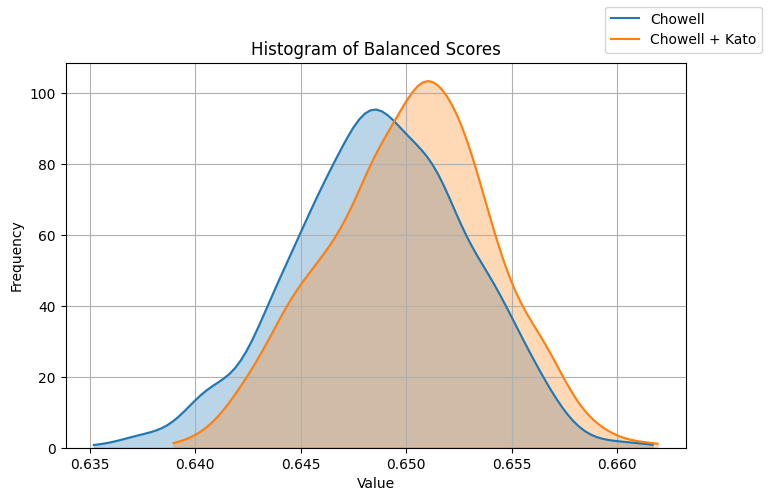

In [69]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 5))

# Only Chowell_train
cond_vector = torch.zeros(len(datasets_ids))
cond_vector[0] = 1

mask = (data['labels'] == cond_vector).all(dim=1)
accs = data['bal_accs'][mask]
aucs = data['auc_scores'][mask]
    
data_plot = accs[:, -1].numpy()

kde = gaussian_kde(data_plot)  # fits a smooth PDF
x = np.linspace(data_plot.min(), data_plot.max(), 100)

y = kde(x)
color = colors[0]
label = 'Chowell'
ax.plot(x, y, color=color, label=label)
ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve

# Chowell_train and Kato
cond_vector = torch.zeros(len(datasets_ids))
cond_vector[0] = 1
cond_vector[5] = 1

mask = (data['labels'] == cond_vector).all(dim=1)
accs = data['bal_accs'][mask]
aucs = data['auc_scores'][mask]
    
data_plot = accs[:, -1].numpy()

kde = gaussian_kde(data_plot)  # fits a smooth PDF
x = np.linspace(data_plot.min(), data_plot.max(), 100)

y = kde(x)
color = colors[1]
label = 'Chowell + Kato'
ax.plot(x, y, color=color, label=label)
ax.fill_between(x, y, alpha=0.3, color=color)  # shadow below curve

# xlim = [0.45, 0.75]

ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_title(f"Histogram of Balanced Scores")
# ax.set_xlim(xlim)
ax.set_ylim(ymin=0)
ax.grid(True, zorder=-1)

fig.legend()

# Show plot
plt.show()

# Attacks

## On all models

### Weak Black-Box attacks

In [3]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

In [44]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        ham_acc_values = []
        f1_values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            X_test, y_test = joblib.load(
                os.path.join(attacker_dir,
                            f'test_set_bb_{attack_name}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            ham_acc = 1 - hamming_loss(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="micro")
            
            ham_acc_values.append(ham_acc)
            f1_values.append(f1)
        
        ham_acc_values = torch.tensor(ham_acc_values)
        f1_values = torch.tensor(f1_values)
        print(f'Ham. Acc. {model_name}: mean = {ham_acc_values.mean():.4f}, std = {ham_acc_values.std():.4f}')
        print(f'f1-score {model_name}: mean = {f1_values.mean():.4f}, std = {f1_values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.7927, std = 0.0062
f1-score lr: mean = 0.7977, std = 0.0058
Ham. Acc. lr_priv: mean = 0.7782, std = 0.0077
f1-score lr_priv: mean = 0.7826, std = 0.0072
Ham. Acc. tt: mean = 0.7166, std = 0.0038
f1-score tt: mean = 0.7221, std = 0.0040

average:
Ham. Acc. lr: mean = 0.8730, std = 0.0113
f1-score lr: mean = 0.8745, std = 0.0113
Ham. Acc. lr_priv: mean = 0.8502, std = 0.0046
f1-score lr_priv: mean = 0.8526, std = 0.0045
Ham. Acc. tt: mean = 0.7404, std = 0.0028
f1-score tt: mean = 0.7455, std = 0.0035



In [62]:
attack_name = 'weak'
scaler_type = 'standard'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
        
    for epsilon in epsilon_list:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', 'lr_dp',
                                    scaler_type, model_type)
        
        ham_acc_values = []
        f1_values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
            X_test, y_test = joblib.load(
                os.path.join(attacker_dir,
                            f'test_set_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            ham_acc = 1 - hamming_loss(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="micro")
            
            ham_acc_values.append(ham_acc)
            f1_values.append(f1)
        
        ham_acc_values = torch.tensor(ham_acc_values)
        f1_values = torch.tensor(f1_values)
        print(f'Ham. Acc. lr_dp eps={epsilon}: mean = {ham_acc_values.mean():.4f}, std = {ham_acc_values.std():.4f}')
        print(f'f1-score lr_dp eps={epsilon}: mean = {f1_values.mean():.4f}, std = {f1_values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr_dp eps=0.01: mean = 0.5412, std = 0.0032
f1-score lr_dp eps=0.01: mean = 0.5728, std = 0.0087
Ham. Acc. lr_dp eps=0.1: mean = 0.5408, std = 0.0028
f1-score lr_dp eps=0.1: mean = 0.5702, std = 0.0084
Ham. Acc. lr_dp eps=1.0: mean = 0.5792, std = 0.0029
f1-score lr_dp eps=1.0: mean = 0.5961, std = 0.0148
Ham. Acc. lr_dp eps=10.0: mean = 0.7055, std = 0.0039
f1-score lr_dp eps=10.0: mean = 0.7227, std = 0.0051
Ham. Acc. lr_dp eps=100.0: mean = 0.7610, std = 0.0071
f1-score lr_dp eps=100.0: mean = 0.7655, std = 0.0082
Ham. Acc. lr_dp eps=inf: mean = 0.7576, std = 0.0072
f1-score lr_dp eps=inf: mean = 0.7612, std = 0.0063

average:
Ham. Acc. lr_dp eps=0.01: mean = 0.5440, std = 0.0022
f1-score lr_dp eps=0.01: mean = 0.5926, std = 0.0094
Ham. Acc. lr_dp eps=0.1: mean = 0.5599, std = 0.0021
f1-score lr_dp eps=0.1: mean = 0.5873, std = 0.0113
Ham. Acc. lr_dp eps=1.0: mean = 0.6476, std = 0.0046
f1-score lr_dp eps=1.0: mean = 0.6613, std = 0.0077
Ham. Acc. lr_dp eps=10.0: 

### Strong Black-Box attacks

In [50]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')

    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        ham_acc_values = []
        f1_values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            X_test, y_test = joblib.load(
                os.path.join(attacker_dir,
                            f'test_set_bb_{attack_name}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            ham_acc = 1 - hamming_loss(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="micro")
            
            ham_acc_values.append(ham_acc)
            f1_values.append(f1)
        
        ham_acc_values = torch.tensor(ham_acc_values)
        f1_values = torch.tensor(f1_values)
        print(f'Ham. Acc. {model_name}: mean = {ham_acc_values.mean():.4f}, std = {ham_acc_values.std():.4f}')
        print(f'f1-score {model_name}: mean = {f1_values.mean():.4f}, std = {f1_values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8798, std = 0.0217
f1-score lr: mean = 0.8803, std = 0.0224
Ham. Acc. lr_priv: mean = 0.8628, std = 0.0081
f1-score lr_priv: mean = 0.8644, std = 0.0076
Ham. Acc. tt: mean = 0.8180, std = 0.0137
f1-score tt: mean = 0.8197, std = 0.0137

average:
Ham. Acc. lr: mean = 0.9502, std = 0.0407
f1-score lr: mean = 0.9507, std = 0.0395
Ham. Acc. lr_priv: mean = 0.9377, std = 0.0130
f1-score lr_priv: mean = 0.9382, std = 0.0128
Ham. Acc. tt: mean = 0.8650, std = 0.0134
f1-score tt: mean = 0.8660, std = 0.0137



In [52]:
attack_name = 'strong'
scaler_type = 'standard'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    
    for epsilon in epsilon_list:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', 'lr_dp',
                                    scaler_type, model_type)
        
        ham_acc_values = []
        f1_values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
            X_test, y_test = joblib.load(
                os.path.join(attacker_dir,
                            f'test_set_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            ham_acc = 1 - hamming_loss(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="micro")
            
            ham_acc_values.append(ham_acc)
            f1_values.append(f1)
        
        ham_acc_values = torch.tensor(ham_acc_values)
        f1_values = torch.tensor(f1_values)
        print(f'Ham. Acc. lr_dp eps={epsilon}: mean = {ham_acc_values.mean():.4f}, std = {ham_acc_values.std():.4f}')
        print(f'f1-score lr_dp eps={epsilon}: mean = {f1_values.mean():.4f}, std = {f1_values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr_dp eps=0.01: mean = 0.5428, std = 0.0043
f1-score lr_dp eps=0.01: mean = 0.5769, std = 0.0128
Ham. Acc. lr_dp eps=0.1: mean = 0.5414, std = 0.0039
f1-score lr_dp eps=0.1: mean = 0.5746, std = 0.0121
Ham. Acc. lr_dp eps=1.0: mean = 0.5871, std = 0.0036
f1-score lr_dp eps=1.0: mean = 0.6054, std = 0.0091
Ham. Acc. lr_dp eps=10.0: mean = 0.7740, std = 0.0058
f1-score lr_dp eps=10.0: mean = 0.7791, std = 0.0066
Ham. Acc. lr_dp eps=100.0: mean = 0.8660, std = 0.0219
f1-score lr_dp eps=100.0: mean = 0.8688, std = 0.0211
Ham. Acc. lr_dp eps=inf: mean = 0.8739, std = 0.0240
f1-score lr_dp eps=inf: mean = 0.8747, std = 0.0241

average:
Ham. Acc. lr_dp eps=0.01: mean = 0.5581, std = 0.0033
f1-score lr_dp eps=0.01: mean = 0.5955, std = 0.0084
Ham. Acc. lr_dp eps=0.1: mean = 0.5717, std = 0.0027
f1-score lr_dp eps=0.1: mean = 0.5940, std = 0.0099
Ham. Acc. lr_dp eps=1.0: mean = 0.6600, std = 0.0026
f1-score lr_dp eps=1.0: mean = 0.6700, std = 0.0079
Ham. Acc. lr_dp eps=10.0: 

### White-Box attacks

In [53]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    
    for model_name in ['lr', 'lr_priv', 'tt']: #, 'lr_tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        ham_acc_values = []
        f1_values = []
        for i in range(25):
            X_test, y_test = joblib.load(
                os.path.join(attacker_dir,
                            f'test_set_wb_{i+1}.pkl'))
            
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            final_preds = (avg_preds >= 0.5).astype(int)

            ham_acc = 1 - hamming_loss(y_test, final_preds)
            f1 = f1_score(y_test, final_preds, average="micro")
            
            ham_acc_values.append(ham_acc)
            f1_values.append(f1)
        
        ham_acc_values = torch.tensor(ham_acc_values)
        f1_values = torch.tensor(f1_values)
        print(f'Ham. Acc. {model_name}: mean = {ham_acc_values.mean():.4f}, std = {ham_acc_values.std():.4f}')
        print(f'f1-score {model_name}: mean = {f1_values.mean():.4f}, std = {f1_values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8995, std = 0.0015
f1-score lr: mean = 0.9004, std = 0.0014
Ham. Acc. lr_priv: mean = 0.8913, std = 0.0014
f1-score lr_priv: mean = 0.8928, std = 0.0015
Ham. Acc. tt: mean = 0.5590, std = 0.0273
f1-score tt: mean = 0.6286, std = 0.0292

average:
Ham. Acc. lr: mean = 0.9974, std = 0.0032
f1-score lr: mean = 0.9974, std = 0.0032
Ham. Acc. lr_priv: mean = 0.9777, std = 0.0050
f1-score lr_priv: mean = 0.9778, std = 0.0050
Ham. Acc. tt: mean = 0.5770, std = 0.0176
f1-score tt: mean = 0.6386, std = 0.0100



In [54]:
scaler_type = 'standard'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    
    for epsilon in epsilon_list:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr_dp',
                                    scaler_type, model_type)
        
        ham_acc_values = []
        f1_values = []
        for i in range(25):
            X_test, y_test = joblib.load(
                os.path.join(attacker_dir,
                            f'test_set_wb_{epsilon}_{i+1}.pkl'))
            
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{epsilon}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            final_preds = (avg_preds >= 0.5).astype(int)

            ham_acc = 1 - hamming_loss(y_test, final_preds)
            f1 = f1_score(y_test, final_preds, average="micro")
            
            ham_acc_values.append(ham_acc)
            f1_values.append(f1)
        
        ham_acc_values = torch.tensor(ham_acc_values)
        f1_values = torch.tensor(f1_values)
        print(f'Ham. Acc. lr_dp eps={epsilon}: mean = {ham_acc_values.mean():.4f}, std = {ham_acc_values.std():.4f}')
        print(f'f1-score lr_dp eps={epsilon}: mean = {f1_values.mean():.4f}, std = {f1_values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr_dp eps=0.01: mean = 0.5258, std = 0.0343
f1-score lr_dp eps=0.01: mean = 0.6015, std = 0.0455
Ham. Acc. lr_dp eps=0.1: mean = 0.5307, std = 0.0365
f1-score lr_dp eps=0.1: mean = 0.6071, std = 0.0342
Ham. Acc. lr_dp eps=1.0: mean = 0.5359, std = 0.0359
f1-score lr_dp eps=1.0: mean = 0.6057, std = 0.0394
Ham. Acc. lr_dp eps=10.0: mean = 0.6379, std = 0.0141
f1-score lr_dp eps=10.0: mean = 0.6491, std = 0.0141
Ham. Acc. lr_dp eps=100.0: mean = 0.8636, std = 0.0083
f1-score lr_dp eps=100.0: mean = 0.8659, std = 0.0090
Ham. Acc. lr_dp eps=inf: mean = 0.8977, std = 0.0030
f1-score lr_dp eps=inf: mean = 0.8986, std = 0.0032

average:
Ham. Acc. lr_dp eps=0.01: mean = 0.6181, std = 0.0051
f1-score lr_dp eps=0.01: mean = 0.6327, std = 0.0075
Ham. Acc. lr_dp eps=0.1: mean = 0.6218, std = 0.0054
f1-score lr_dp eps=0.1: mean = 0.6314, std = 0.0077
Ham. Acc. lr_dp eps=1.0: mean = 0.6913, std = 0.0047
f1-score lr_dp eps=1.0: mean = 0.6927, std = 0.0068
Ham. Acc. lr_dp eps=10.0: 

## On models with high accuracy

### Weak Black-Box attacks

In [18]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

In [63]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        # mask = data['labels'][:, 0] == 1
        mask = data['bal_accs'][:, -1] >= 0.65
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]  
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask]       
        
        X_test, y_test = bin_scores, labels
        
        values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            val = 1 - hamming_loss(y_test, y_pred)
            # val = f1_score(y_test, y_pred, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.7439, std = 0.0041
Metrics lr_priv: mean = 0.7340, std = 0.0066
Metrics tt: mean = 0.6862, std = 0.0044

average:
Metrics lr: mean = 0.8461, std = 0.0114
Metrics lr_priv: mean = 0.8226, std = 0.0048
Metrics tt: mean = 0.7180, std = 0.0028



### Strong Black-Box attacks

In [64]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')

    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        # mask = data['labels'][:, 0] == 1
        mask = data['bal_accs'][:, -1] >= 0.65
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]  
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask]       
        
        X_test, y_test = out_scores, labels
        
        values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            val = 1 - hamming_loss(y_test, y_pred)
            # val = f1_score(y_test, y_pred, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.8561, std = 0.0215
Metrics lr_priv: mean = 0.8345, std = 0.0090
Metrics tt: mean = 0.8008, std = 0.0128

average:
Metrics lr: mean = 0.9440, std = 0.0434
Metrics lr_priv: mean = 0.9300, std = 0.0141
Metrics tt: mean = 0.8680, std = 0.0133



### White-Box attacks

In [65]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    
    for model_name in ['lr', 'lr_priv', 'tt']: #, 'lr_tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        # mask = data['labels'][:, 0] == 1
        mask = data['bal_accs'][:, -1] >= 0.65
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]  
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask]       
        
        X_test, y_test = params, labels
        
        values = []
        for i in range(25):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            final_preds = (avg_preds >= 0.5).astype(int)

            val = 1 - hamming_loss(y_test, final_preds)
            # val = f1_score(y_test, final_preds, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.8803, std = 0.0009
Metrics lr_priv: mean = 0.8692, std = 0.0013
Metrics tt: mean = 0.5653, std = 0.0297

average:
Metrics lr: mean = 0.9975, std = 0.0033
Metrics lr_priv: mean = 0.9737, std = 0.0060
Metrics tt: mean = 0.5786, std = 0.0098



## On models trained on Chowell_train plus other datasets

### Weak Black-Box attacks

In [39]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

In [66]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        mask = data['labels'][:, 0] == 1
        # mask = data['bal_accs'][:, -1] >= 0.65
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]  
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask]       
        
        X_test, y_test = bin_scores, labels
        
        values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            val = 1 - hamming_loss(y_test, y_pred)
            # val = f1_score(y_test, y_pred, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.7426, std = 0.0043
Metrics lr_priv: mean = 0.7316, std = 0.0070
Metrics tt: mean = 0.6746, std = 0.0030

average:
Metrics lr: mean = 0.8423, std = 0.0108
Metrics lr_priv: mean = 0.8160, std = 0.0041
Metrics tt: mean = 0.6978, std = 0.0026



### Strong Black-Box attacks

In [67]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')

    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        mask = data['labels'][:, 0] == 1
        # mask = data['bal_accs'][:, -1] >= 0.65
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]  
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask]       
        
        X_test, y_test = out_scores, labels
        
        values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            val = 1 - hamming_loss(y_test, y_pred)
            # val = f1_score(y_test, y_pred, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.8531, std = 0.0196
Metrics lr_priv: mean = 0.8307, std = 0.0080
Metrics tt: mean = 0.7878, std = 0.0118

average:
Metrics lr: mean = 0.9459, std = 0.0432
Metrics lr_priv: mean = 0.9294, std = 0.0141
Metrics tt: mean = 0.8466, std = 0.0118



### White-Box attacks

In [68]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    
    for model_name in ['lr', 'lr_priv', 'tt']: #, 'lr_tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        mask = data['labels'][:, 0] == 1
        # mask = data['bal_accs'][:, -1] >= 0.65
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask]
        
        X_test, y_test = params, labels
        
        values = []
        for i in range(25):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            final_preds = (avg_preds >= 0.5).astype(int)

            val = 1 - hamming_loss(y_test, final_preds)
            # val = f1_score(y_test, final_preds, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.8782, std = 0.0010
Metrics lr_priv: mean = 0.8640, std = 0.0014
Metrics tt: mean = 0.5452, std = 0.0318

average:
Metrics lr: mean = 0.9976, std = 0.0032
Metrics lr_priv: mean = 0.9747, std = 0.0058
Metrics tt: mean = 0.5663, std = 0.0090



## On models trained on Chowell_train vs Chowell_train + Kato

### Weak Black-Box attacks

In [70]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

In [75]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        masks = []
        for dataset_name in ['Chowell', 'ChowellKato']:
            cond_vector = torch.zeros(len(datasets_ids))
            cond_vector[0] = 1
            if dataset_name == 'ChowellKato':
                cond_vector[5] = 1
            
            mask = (data['labels'] == cond_vector).all(dim=1)
            masks.append(mask)
        
        mask = masks[0] + masks[1]
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]  
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask] 
        
        cond_vector = torch.zeros(len(datasets_ids))
        cond_vector[0] = 1
        cond_vector[5] = 1
        aux_mask = (labels == cond_vector).all(dim=1)    
        
        X_test, y_test = bin_scores, labels
        
        values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            val = 1 - hamming_loss(y_test[aux_mask], y_pred[aux_mask])
            # val = 1 - hamming_loss(y_test, y_pred)
            # val = f1_score(y_test, y_pred, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.6755, std = 0.0342
Metrics lr_priv: mean = 0.7108, std = 0.0327
Metrics tt: mean = 0.6502, std = 0.0292

average:
Metrics lr: mean = 0.8244, std = 0.0726
Metrics lr_priv: mean = 0.7432, std = 0.0441
Metrics tt: mean = 0.6553, std = 0.0447



### Strong Black-Box attacks

In [ ]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')

    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        masks = []
        for dataset_name in ['Chowell', 'ChowellKato']:
            cond_vector = torch.zeros(len(datasets_ids))
            cond_vector[0] = 1
            if dataset_name == 'ChowellKato':
                cond_vector[5] = 1
            
            mask = (data['labels'] == cond_vector).all(dim=1)
            masks.append(mask)
        
        mask = masks[0] + masks[1]
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]  
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask]   
        
        cond_vector = torch.zeros(len(datasets_ids))
        cond_vector[0] = 1
        cond_vector[5] = 1
        aux_mask = (labels == cond_vector).all(dim=1) 
        
        X_test, y_test = out_scores, labels
        
        values = []
        for i in range(25):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            y_pred = mlp_bb.predict(X_test)

            val = 1 - hamming_loss(y_test[aux_mask], y_pred[aux_mask])
            # val = 1 - hamming_loss(y_test, y_pred)
            # val = f1_score(y_test, y_pred, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.8339, std = 0.0561
Metrics lr_priv: mean = 0.8109, std = 0.0685
Metrics tt: mean = 0.7918, std = 0.0580

average:
Metrics lr: mean = 0.9362, std = 0.0688
Metrics lr_priv: mean = 0.8475, std = 0.0585
Metrics tt: mean = 0.8374, std = 0.0527



### White-Box attacks

In [79]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    
    for model_name in ['lr', 'lr_priv', 'tt']: #, 'lr_tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        masks = []
        for dataset_name in ['Chowell', 'ChowellKato']:
            cond_vector = torch.zeros(len(datasets_ids))
            cond_vector[0] = 1
            if dataset_name == 'ChowellKato':
                cond_vector[5] = 1
            
            mask = (data['labels'] == cond_vector).all(dim=1)
            masks.append(mask)
        
        mask = masks[0] + masks[1]
        
        if model_name == 'tt':
            params = data['cores'][mask]
        else:
            params = data['params'][mask]
        labels = data['labels'][mask]
        accs = data['bal_accs'][mask]
        aucs = data['auc_scores'][mask]
        out_scores = data['out_scores'][mask]
        bin_scores = data['bin_scores'][mask]
        
        cond_vector = torch.zeros(len(datasets_ids))
        cond_vector[0] = 1
        cond_vector[5] = 1
        aux_mask = (labels == cond_vector).all(dim=1)
        
        X_test, y_test = params, labels
        
        values = []
        for i in range(25):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            final_preds = (avg_preds >= 0.5).astype(int)

            val = 1 - hamming_loss(y_test[aux_mask], final_preds[aux_mask])
            # val = 1 - hamming_loss(y_test, y_pred)
            # val = f1_score(y_test, y_pred, average="micro")
            
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Metrics {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Metrics lr: mean = 0.8395, std = 0.0100
Metrics lr_priv: mean = 0.8961, std = 0.0113
Metrics tt: mean = 0.4755, std = 0.0912

average:
Metrics lr: mean = 0.9999, std = 0.0004
Metrics lr_priv: mean = 0.9475, std = 0.0356
Metrics tt: mean = 0.5515, std = 0.0612

